# 🧠 Deep Learning Lab Assignment  
## Foundations of Machine Learning Frameworks (CSCN8010)

---

### 📌 Student Information
- **Name:** Zhuoran Zhang  
- **Student ID:** 9048508  

---

### 📚 Course Information
- **Course:** Foundations of Machine Learning Frameworks  
- **Course Code:** CSCN8010  

---

### 📝 Assignment Title
**Transfer Learning and Fine-Tuning for Image Classification (Dogs vs Cats)**

---

### 🎯 Objective
The objective of this lab is to apply a common deep learning workflow by leveraging a pre-trained model and fine-tuning it for a specific image classification task. The assignment focuses on model development, evaluation, and performance comparison using both a custom neural network and a fine-tuned VGG16 model.

---

### 🛠️ Key Tasks
- Perform **Exploratory Data Analysis (EDA)** on the dataset  
- Build and train a **custom neural network model**  
- Apply **transfer learning with VGG16 (ImageNet pre-trained)**  
- Evaluate models using:
  - Accuracy  
  - Confusion Matrix  
  - Precision, Recall, F1-score  
  - Precision-Recall Curve  
- Conduct **error analysis** on misclassified samples  
- Compare model performances and draw conclusions  


## 📚 Import Library

In [ ]:
import os
import shutil
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from pathlib import Path

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score
)

### 💾 Save Plots to Images Folder

This utility creates an `../images` directory (if it does not already exist) and defines a helper function to save all generated plots.  
Saving figures ensures reproducibility, improves report quality, and allows easy reuse of visuals in the final PDF or presentation.

In [63]:
# Create images folder
images_dir = Path("../images")
images_dir.mkdir(parents=True, exist_ok=True)

def save_plot(filename):
    plt.savefig(images_dir / filename, bbox_inches="tight", dpi=300)

## 📂 Dataset Preparation: Creating Training, Validation, and Test Subsets

The original Dogs vs Cats dataset contains 25,000 images, but only a smaller subset is required for this lab.  
To keep the experiments manageable, the dataset is divided into:

- **Training set:** 1000 cat images + 1000 dog images  
- **Validation set:** 500 cat images + 500 dog images  
- **Test set:** 1000 cat images + 1000 dog images  

This balanced split ensures that both classes are equally represented in each subset.

In [17]:
# the training set may have been obtained from https://www.kaggle.com/c/dogs-vs-cats/data or 
# from https://www.microsoft.com/en-us/download/details.aspx?id=54765 or
# from https://www.tensorflow.org/datasets/catalog/cats_vs_dogs or
# from https://huggingface.co/datasets/microsoft/cats_vs_dogs
# or from another source, but in any case it should be unzipped and available at ../data/kaggle_dogs_vs_cats/train
# NOTE: the original training set contains 25,000 images of cats and dogs, but we will only use a subset of it for our experiments
# NOTE: the exact paths and the names of the image files may differ depending on the source of the dataset, so you may need to adjust 
# the code below accordingly 
original_dir = pathlib.Path("../data/kaggle_dogs_vs_cats/train")
new_base_dir = pathlib.Path("../data/kaggle_dogs_vs_cats_small")

def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir, exist_ok=True)  # Added exist_ok to avoid errors if folder exists
        # Filenames are just numbers: 1.jpg, 2.jpg, etc.
        fnames = [f"{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            src = original_dir / category.capitalize() / fname  # e.g., Cat/1.jpg or Dog/1.jpg
            dst = dir / fname
            if src.exists():  # Check if source file exists before copying
                shutil.copyfile(src, dst)
            else:
                print(f"Warning: {src} not found, skipping.")

make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

In [18]:
base_dir = pathlib.Path("../data/kaggle_dogs_vs_cats_small")

for subset in ["train", "validation", "test"]:
    print(f"\n{subset.upper()} SET")
    for category in ["cat", "dog"]:
        folder = base_dir / subset / category
        count = len(list(folder.glob("*.jpg")))
        print(f"{category}: {count} images")


TRAIN SET
cat: 1000 images
dog: 1000 images

VALIDATION SET
cat: 500 images
dog: 500 images

TEST SET
cat: 1000 images
dog: 1000 images


## ✅ Dataset Check

The output above confirms that the dataset has been successfully split into training, validation, and test subsets.  
Each subset contains a balanced number of cat and dog images, which is important for fair model training and evaluation.

This preparation step ensures that:
- the model learns from a representative sample,
- validation can be used to monitor overfitting,
- and final performance can be measured on unseen test data.

## 📊 Exploratory Data Analysis (EDA)

Before training the models, it is important to explore the dataset visually and statistically.  
This step helps us understand the class distribution, inspect sample images, and identify whether there are any obvious issues such as class imbalance or inconsistent image properties.

The EDA in this lab focuses on:
- visualizing example images,
- checking class balance,
- and examining image dimensions.

### Visualize some sample images from the training set

This step is performed to visually inspect the dataset and understand the variability in images before training the model.

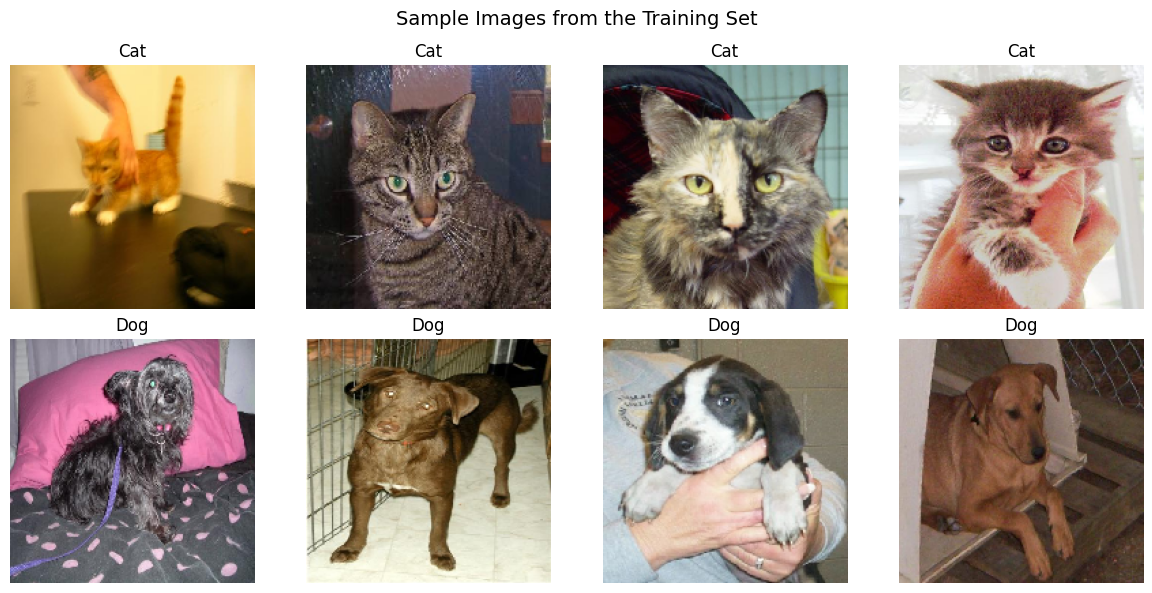

In [19]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img

train_cat_dir = base_dir / "train" / "cat"
train_dog_dir = base_dir / "train" / "dog"

cat_images = list(train_cat_dir.glob("*.jpg"))[:4]
dog_images = list(train_dog_dir.glob("*.jpg"))[:4]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, img_path in enumerate(cat_images):
    img = load_img(img_path, target_size=(180, 180))
    axes[0, i].imshow(img)
    axes[0, i].set_title("Cat")
    axes[0, i].axis("off")

for i, img_path in enumerate(dog_images):
    img = load_img(img_path, target_size=(180, 180))
    axes[1, i].imshow(img)
    axes[1, i].set_title("Dog")
    axes[1, i].axis("off")

plt.suptitle("Sample Images from the Training Set", fontsize=14)
plt.tight_layout()
plt.show()

### Observation

The sample images show clear visual differences between cats and dogs, but there is also significant variation in pose, background, lighting, and fur color.  
This variation makes the task more realistic and slightly challenging, which is suitable for evaluating the generalization ability of deep learning models.

### Visualize class distribution across dataset splits

This step is performed to verify that the dataset is balanced across different splits, ensuring that the model is not biased toward any class.

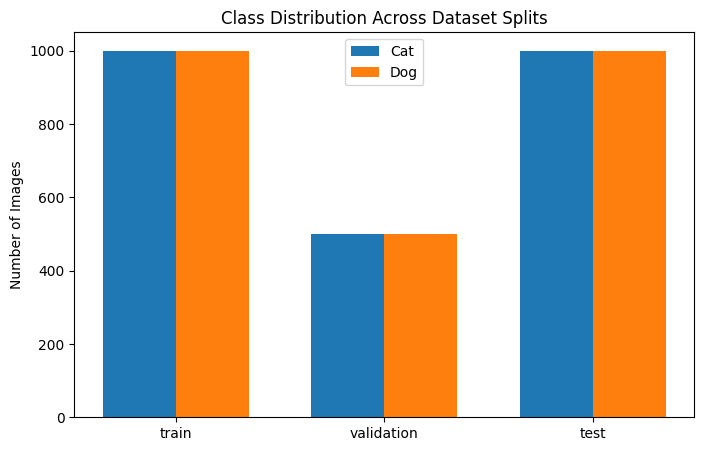

<Figure size 640x480 with 0 Axes>

In [64]:
subsets = ["train", "validation", "test"]
categories = ["cat", "dog"]

counts = {}
for subset in subsets:
    counts[subset] = []
    for category in categories:
        folder = base_dir / subset / category
        counts[subset].append(len(list(folder.glob("*.jpg"))))

x = np.arange(len(subsets))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, [counts[s][0] for s in subsets], width, label="Cat")
plt.bar(x + width/2, [counts[s][1] for s in subsets], width, label="Dog")

plt.xticks(x, subsets)
plt.ylabel("Number of Images")
plt.title("Class Distribution Across Dataset Splits")
plt.legend()
plt.show()

save_plot("dataset_distribution.png")

### Insight

The dataset is perfectly balanced across all three splits.  
This is beneficial because it reduces the risk of model bias toward one class and makes accuracy a more meaningful evaluation metric.

### Check the sizes of the images in the training set

This step is performed to examine the variation in image dimensions and ensure consistent resizing before feeding the data into the model.

In [21]:
from PIL import Image

sample_paths = list(train_cat_dir.glob("*.jpg"))[:10] + list(train_dog_dir.glob("*.jpg"))[:10]

image_sizes = []
for path in sample_paths:
    with Image.open(path) as img:
        image_sizes.append(img.size)

image_sizes[:10]

[(500, 375),
 (300, 281),
 (489, 500),
 (403, 500),
 (297, 200),
 (350, 343),
 (500, 387),
 (253, 400),
 (215, 175),
 (400, 375)]

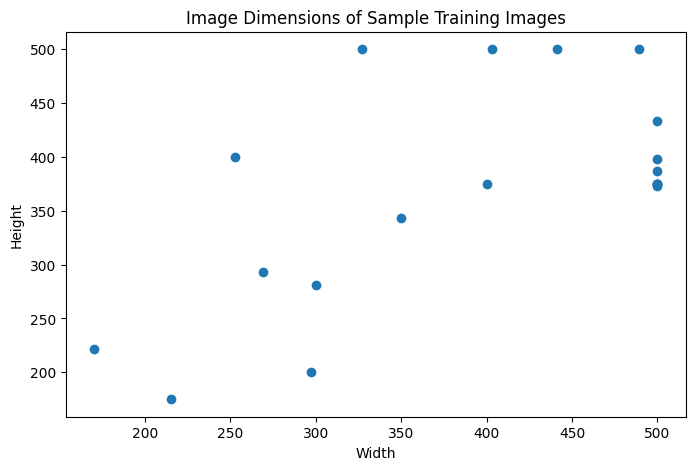

Average width: 395.7
Average height: 369.0


<Figure size 640x480 with 0 Axes>

In [65]:
widths = [size[0] for size in image_sizes]
heights = [size[1] for size in image_sizes]

plt.figure(figsize=(8, 5))
plt.scatter(widths, heights)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Image Dimensions of Sample Training Images")
plt.show()

print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

save_plot("image_dimensions_scatter.png")

### Observations

The scatter plot shows that the image dimensions vary significantly across the training dataset, with widths and heights ranging roughly from 175 to 500 pixels. There is no fixed or consistent image size, and both width and height vary independently.

This variability confirms that the dataset is not standardized in terms of image dimensions. Therefore, resizing all images to a uniform size (e.g., 180×180) is necessary before feeding them into the neural network, ensuring compatibility with the model architecture and stable training.

## 📱 Model 1: MobileNetV2

In this section, MobileNetV2 is used as the first network for image classification. MobileNetV2 is a lightweight pre-trained model trained on ImageNet, known for its efficiency and fast training speed.

Initially, the convolutional base is used as a fixed feature extractor with frozen weights, while a small custom classifier is trained on top for binary classification. 

After this initial training stage, fine-tuning is applied by unfreezing the top layers of the convolutional base and retraining the model with a very low learning rate. This allows the model to slightly adjust high-level features and better adapt to the cats-vs-dogs dataset, potentially improving performance.

### Load Dataset for MobileNetV2

This step loads and resizes the images into batches from the directory structure, ensuring consistent input size and efficient data feeding for model training.

In [23]:
image_size = (180, 180)
batch_size = 32

train_dataset_mobilenet = image_dataset_from_directory(
    base_dir / "train",
    image_size=image_size,
    batch_size=batch_size
)

validation_dataset_mobilenet = image_dataset_from_directory(
    base_dir / "validation",
    image_size=image_size,
    batch_size=batch_size
)

test_dataset_mobilenet = image_dataset_from_directory(
    base_dir / "test",
    image_size=image_size,
    batch_size=batch_size
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


### Preprocessing and Performance Optimization

This step applies the MobileNetV2-specific preprocessing to scale inputs to the expected range and uses prefetching to improve data pipeline efficiency and speed up training.

In [24]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset_mobilenet = train_dataset_mobilenet.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
).prefetch(AUTOTUNE)

validation_dataset_mobilenet = validation_dataset_mobilenet.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
).prefetch(AUTOTUNE)

test_dataset_mobilenet = test_dataset_mobilenet.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
).prefetch(AUTOTUNE)

### Build the MobileNetV2 Model

The MobileNetV2 convolutional base is loaded with pre-trained ImageNet weights and frozen initially.  
A custom classification head is then added for the cats-vs-dogs task.

In [25]:
conv_base_mobile = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3)
)

conv_base_mobile.trainable = False

C:\Users\85155\AppData\Local\Temp\ipykernel_6572\1714686633.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  conv_base_mobile = MobileNetV2(


In [26]:
inputs = keras.Input(shape=(180, 180, 3))
x = conv_base_mobile(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

mobilenet_model = keras.Model(inputs, outputs)

### Compilation

The model is compiled using binary cross-entropy loss for binary classification and Adam as the optimizer.  
Accuracy is used as the main evaluation metric.

In [27]:
mobilenet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### Model Checkpoint

ModelCheckpoint is used to save the best version of the model based on validation loss.  
This ensures that the best-performing model is retained for later evaluation.

In [ ]:
mobilenet_callbacks = [
    ModelCheckpoint(
        filepath="../models/best_mobilenetv2_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

### Training

The model is trained on the training set and validated on the validation set.  
Since the convolutional base is frozen, only the classifier layers are updated during this stage.

In [29]:
mobilenet_history = mobilenet_model.fit(
    train_dataset_mobilenet,
    epochs=20,
    validation_data=validation_dataset_mobilenet,
    callbacks=mobilenet_callbacks
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 153ms/step - accuracy: 0.9500 - loss: 0.1263 - val_accuracy: 0.9830 - val_loss: 0.0541
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.9795 - loss: 0.0551 - val_accuracy: 0.9870 - val_loss: 0.0455
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.9885 - loss: 0.0344 - val_accuracy: 0.9810 - val_loss: 0.0572
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9905 - loss: 0.0275 - val_accuracy: 0.9830 - val_loss: 0.0565
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.9865 - loss: 0.0295 - val_accuracy: 0.9850 - val_loss: 0.0554
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step - accuracy: 0.9920 - loss: 0.0189 - val_accuracy: 0.9870 - val_loss: 0.0550
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.9950 - loss: 0.0106 - val_accuracy: 0.9790 - val_loss: 0.0659
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.9960 - loss: 0.0141 - val_accuracy

### Load the Best Saved Model

After training, the best saved version of the model is loaded for further evaluation and comparison.

In [ ]:
mobilenet_model = keras.models.load_model("../models/best_mobilenetv2_model.keras")

### Training Performance

The following plots show the training and validation accuracy and loss across epochs.  
These curves help evaluate learning progress and detect overfitting.

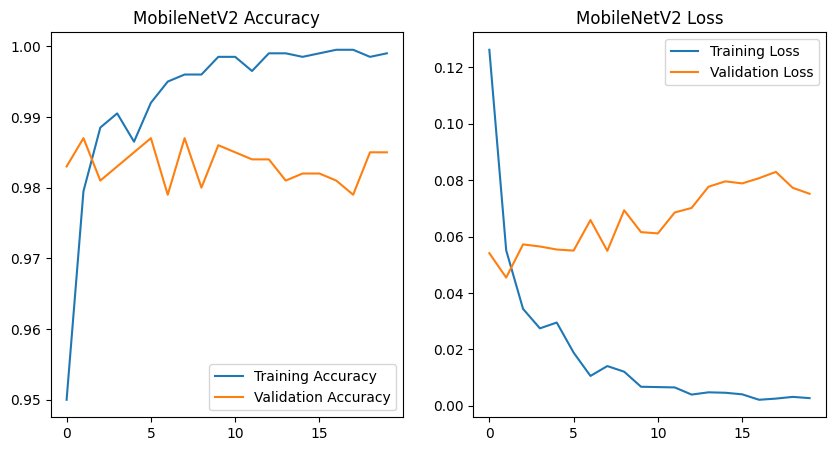

<Figure size 640x480 with 0 Axes>

In [66]:
acc = mobilenet_history.history["accuracy"]
val_acc = mobilenet_history.history["val_accuracy"]
loss = mobilenet_history.history["loss"]
val_loss = mobilenet_history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("MobileNetV2 Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("MobileNetV2 Loss")

plt.show()

save_plot("mobilenet_before_finetuning.png")

### Observation

The MobileNetV2 model performs very strongly on both the training and validation sets. Training accuracy increases rapidly and approaches 100%, while validation accuracy remains consistently high at around 98%–98.5%.

Although the training loss continues to decrease toward zero, the validation loss stays relatively low and stable for most epochs, with only small fluctuations. This suggests that the model generalizes well overall, with only mild signs of overfitting in the later epochs.

Compared with the previous baseline model, MobileNetV2 achieves much better validation performance and shows stronger feature extraction capability. This indicates that transfer learning with a lightweight pre-trained network is highly effective for the cats-vs-dogs classification task.

### Fine-Tuning MobileNetV2

After training the classifier with the frozen convolutional base, fine-tuning is applied to further adapt the pre-trained model to the cats-vs-dogs dataset.

In this step, the top layers of MobileNetV2 are unfrozen while the earlier layers remain frozen. A very low learning rate is used to make small adjustments to the pre-trained weights without destroying the useful features learned from ImageNet.

In [32]:
conv_base_mobile.trainable = True

for layer in conv_base_mobile.layers[:-20]:
    layer.trainable = False

### Recompile for Fine-Tuning

The model must be recompiled after changing layer trainability.  
A low learning rate is used to ensure that fine-tuning updates the pre-trained weights gradually and safely.

In [33]:
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### Model Checkpoint for Fine-Tuning

A new checkpoint is used to save the best version of the fine-tuned MobileNetV2 model based on validation loss.

In [ ]:
mobilenet_finetune_callbacks = [
    ModelCheckpoint(
        filepath="../models/best_mobilenetv2_finetuned.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

### Fine-Tuning Training

The model is trained again after unfreezing the top layers.  
This allows the pre-trained feature extractor to better adapt to the target dataset.

In [35]:
mobilenet_finetune_history = mobilenet_model.fit(
    train_dataset_mobilenet,
    epochs=30,
    validation_data=validation_dataset_mobilenet,
    callbacks=mobilenet_finetune_callbacks
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 0.9885 - loss: 0.0328 - val_accuracy: 0.9860 - val_loss: 0.0452
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step - accuracy: 0.9900 - loss: 0.0312 - val_accuracy: 0.9860 - val_loss: 0.0452
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 211ms/step - accuracy: 0.9950 - loss: 0.0234 - val_accuracy: 0.9850 - val_loss: 0.0452
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 196ms/step - accuracy: 0.9930 - loss: 0.0237 - val_accuracy: 0.9850 - val_loss: 0.0452
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 203ms/step - accuracy: 0.9915 - loss: 0.0280 - val_accuracy: 0.9850 - val_loss: 0.0452
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step - accuracy: 0.9900 - loss: 0.0248 - val_accuracy: 0.9850 - val_loss: 0.0452
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.9900 - loss: 0.0279 - val_accuracy: 0.9850 - val_loss: 0.0452
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step - accuracy: 0.9930 - loss: 0.0218 - val_accu

### Load the Best Fine-Tuned Model

After fine-tuning, the best saved model is loaded for evaluation and comparison.

In [ ]:
mobilenet_model = keras.models.load_model("../models/best_mobilenetv2_finetuned.keras")

### Fine-Tuning Performance

The following plots show the training and validation accuracy and loss during the fine-tuning stage.  
These curves help determine whether fine-tuning improves performance or introduces overfitting.

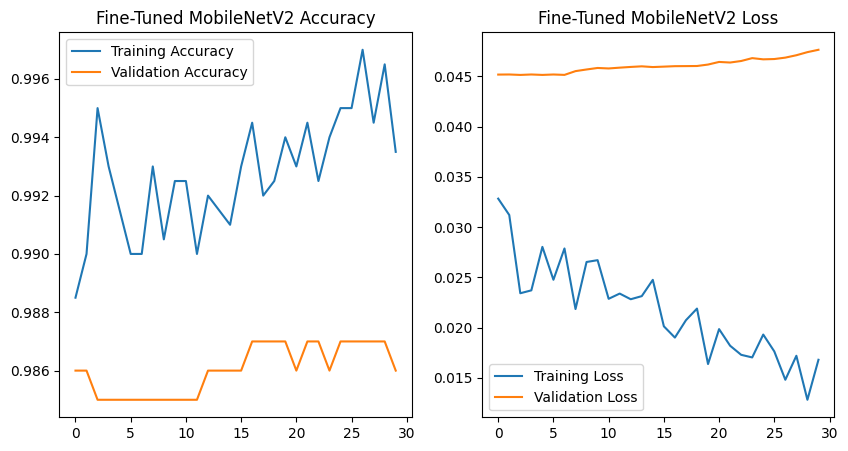

<Figure size 640x480 with 0 Axes>

In [67]:
acc = mobilenet_finetune_history.history["accuracy"]
val_acc = mobilenet_finetune_history.history["val_accuracy"]
loss = mobilenet_finetune_history.history["loss"]
val_loss = mobilenet_finetune_history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Fine-Tuned MobileNetV2 Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("Fine-Tuned MobileNetV2 Loss")

plt.show()

save_plot("mobilenet_after_finetuning.png")

### Fine-Tuned MobileNetV2 Performance Analysis

The fine-tuned MobileNetV2 model achieves very high training accuracy, approaching nearly 100%, indicating that the model fits the training data extremely well. However, the validation accuracy remains relatively stable around 98.5%–98.7%, showing only slight improvement after fine-tuning.

From the loss curves, the training loss continues to decrease steadily, while the validation loss shows a slight upward trend. This divergence suggests that the model begins to overfit during the fine-tuning stage.

Overall, fine-tuning provides only marginal improvement in validation performance while increasing the risk of overfitting. This indicates that the pre-trained MobileNetV2 features were already highly effective for this task, and additional fine-tuning offers limited benefit.

## 🧠 Model 2: VGG16

### Explanation

In this section, VGG16 is used as the second network for image classification. VGG16 is a classic pre-trained convolutional neural network trained on ImageNet and is known for its strong feature extraction capability.

First, the convolutional base is used as a fixed feature extractor with frozen weights. Then, fine-tuning is applied by unfreezing the top layers and retraining them with a low learning rate so that the model can better adapt to the cats-vs-dogs classification task.

### Load Dataset for VGG16

This step loads the dataset and resizes the images into batches so that they can be processed consistently by the VGG16 model.

In [38]:
image_size = (180, 180)
batch_size = 32

train_dataset_vgg = image_dataset_from_directory(
    base_dir / "train",
    image_size=image_size,
    batch_size=batch_size
)

validation_dataset_vgg = image_dataset_from_directory(
    base_dir / "validation",
    image_size=image_size,
    batch_size=batch_size
)

test_dataset_vgg = image_dataset_from_directory(
    base_dir / "test",
    image_size=image_size,
    batch_size=batch_size
)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


### Preprocessing and Performance Optimization

This step applies the VGG16-specific preprocessing function so that the inputs match the format expected by the pre-trained network. Prefetching is also used to improve data pipeline efficiency during training.

In [39]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset_vgg = train_dataset_vgg.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
).prefetch(AUTOTUNE)

validation_dataset_vgg = validation_dataset_vgg.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
).prefetch(AUTOTUNE)

test_dataset_vgg = test_dataset_vgg.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
).prefetch(AUTOTUNE)

### Build the VGG16 Model

The VGG16 convolutional base is loaded with pre-trained ImageNet weights and frozen at first. A custom classifier is then added on top for binary image classification.

In [40]:
conv_base_vgg = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3)
)

conv_base_vgg.trainable = False

In [41]:
inputs = keras.Input(shape=(180, 180, 3))
x = conv_base_vgg(inputs, training=False)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

vgg_model = keras.Model(inputs, outputs)

### Compilation

The model is compiled using binary cross-entropy loss and the Adam optimizer. Accuracy is used as the primary evaluation metric for this binary classification task.

In [42]:
vgg_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### Model Checkpoint

ModelCheckpoint is used to save the best version of the VGG16 model during training based on validation loss.

In [ ]:
vgg_callbacks = [
    ModelCheckpoint(
        filepath="../models/best_vgg16_model.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

### Initial Training with Frozen VGG16 Base

At this stage, the VGG16 convolutional base remains frozen, and only the custom classifier layers are trained. This allows the model to use pre-trained visual features while adapting the classification head to the new task.

In [46]:
vgg_history = vgg_model.fit(
    train_dataset_vgg,
    epochs=20,
    validation_data=validation_dataset_vgg,
    callbacks=vgg_callbacks
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 55s 882ms/step - accuracy: 0.9150 - loss: 0.2092 - val_accuracy: 0.9030 - val_loss: 0.2031
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 56s 888ms/step - accuracy: 0.9550 - loss: 0.1281 - val_accuracy: 0.9440 - val_loss: 0.1336
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 56s 896ms/step - accuracy: 0.9760 - loss: 0.0696 - val_accuracy: 0.9460 - val_loss: 0.1278
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 57s 904ms/step - accuracy: 0.9790 - loss: 0.0557 - val_accuracy: 0.9410 - val_loss: 0.1365
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 57s 904ms/step - accuracy: 0.9900 - loss: 0.0283 - val_accuracy: 0.9460 - val_loss: 0.1542
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 57s 909ms/step - accuracy: 0.9945 - loss: 0.0183 - val_accuracy: 0.9410 - val_loss: 0.1566
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 57s 914ms/step - accuracy: 0.9930 - loss: 0.0193 - val_accuracy: 0.9420 - val_loss: 0.1721
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 57s 908ms/step - accuracy: 0.9965 - loss: 0.0129 - val_accu

### Load the Best Initial VGG16 Model

The best saved version from the initial training stage is loaded before starting fine-tuning.

In [ ]:
vgg_model = keras.models.load_model("../models/best_vgg16_model.keras")

### 📊 VGG16 Performance (Before Fine-Tuning)

This plot shows the training and validation performance of VGG16 when the convolutional base is frozen.

At this stage, only the classifier layers are trained while the pre-trained feature extractor remains unchanged. The results help evaluate how well the pre-trained features generalize to the new dataset before applying fine-tuning.

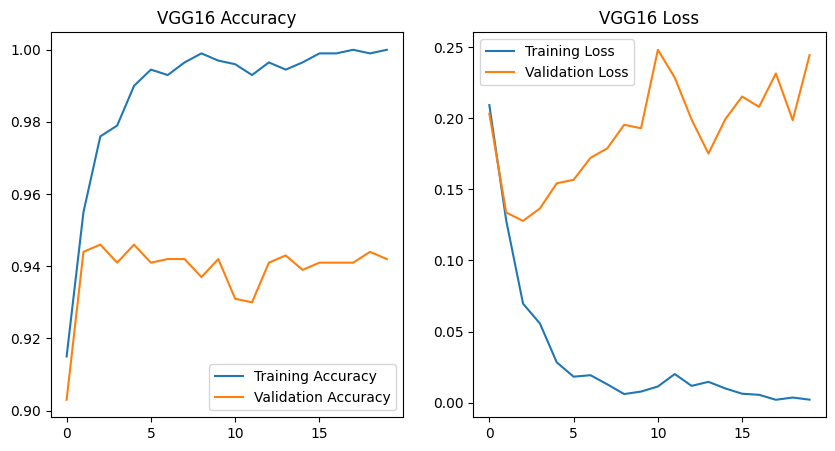

<Figure size 640x480 with 0 Axes>

In [68]:
acc = vgg_history.history["accuracy"]
val_acc = vgg_history.history["val_accuracy"]
loss = vgg_history.history["loss"]
val_loss = vgg_history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("VGG16 Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("VGG16 Loss")

plt.show()

save_plot("vgg_before_finetuning.png")

### VGG16 Performance Observations

The VGG16 model achieves very high training accuracy, quickly approaching nearly 100%, which indicates that the classifier is able to learn the training data extremely well.

However, the validation accuracy stabilizes around 94%–95% and does not improve further after the initial epochs. At the same time, the validation loss steadily increases while the training loss continues to decrease.

This divergence between training and validation performance clearly indicates overfitting. The model is memorizing the training data but fails to generalize effectively to unseen data.

These results suggest that although VGG16 provides powerful feature extraction, the model may be too complex for the dataset, and fine-tuning or additional regularization is required to improve generalization.

### Fine-Tuning VGG16

After initial training, fine-tuning is applied by unfreezing the top layers of VGG16 while keeping the earlier layers frozen. This allows the model to slightly adapt higher-level features to the cats-vs-dogs dataset.

In [55]:
conv_base_vgg.trainable = True

for layer in conv_base_vgg.layers[:-4]:
    layer.trainable = False

### Recompile for Fine-Tuning

The model must be recompiled after changing layer trainability. A very low learning rate is used to prevent large updates to the pre-trained weights during fine-tuning.

In [56]:
vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### Model Checkpoint for Fine-Tuning

A new checkpoint is used to save the best fine-tuned version of the VGG16 model based on validation loss.

In [ ]:
vgg_finetune_callbacks = [
    ModelCheckpoint(
        filepath="../models/best_vgg16_finetuned.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

### Fine-Tuning Training

The model is trained again after unfreezing the top layers. This stage helps the pre-trained network better adapt to the target classification task.

In [58]:
vgg_finetune_history = vgg_model.fit(
    train_dataset_vgg,
    epochs=30,
    validation_data=validation_dataset_vgg,
    callbacks=vgg_finetune_callbacks
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 60s 942ms/step - accuracy: 0.9885 - loss: 0.0297 - val_accuracy: 0.9450 - val_loss: 0.1393
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9935 - loss: 0.0264 - val_accuracy: 0.9460 - val_loss: 0.1395
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9940 - loss: 0.0239 - val_accuracy: 0.9450 - val_loss: 0.1409
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9905 - loss: 0.0291 - val_accuracy: 0.9450 - val_loss: 0.1404
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9955 - loss: 0.0226 - val_accuracy: 0.9450 - val_loss: 0.1404
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9955 - loss: 0.0232 - val_accuracy: 0.9460 - val_loss: 0.1410
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9935 - loss: 0.0260 - val_accuracy: 0.9450 - val_loss: 0.1409
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.9930 - loss: 0.0228 - val_accuracy: 0.9460 - val_lo

### Load the Best Fine-Tuned VGG16 Model

After fine-tuning, the best saved model is loaded for evaluation and comparison.

In [59]:
vgg_model = keras.models.load_model("best_vgg16_finetuned.keras")

### Fine-Tuning Performance

The following plots show the training and validation accuracy and loss during the fine-tuning stage. These curves help assess whether fine-tuning improves performance and whether overfitting occurs.

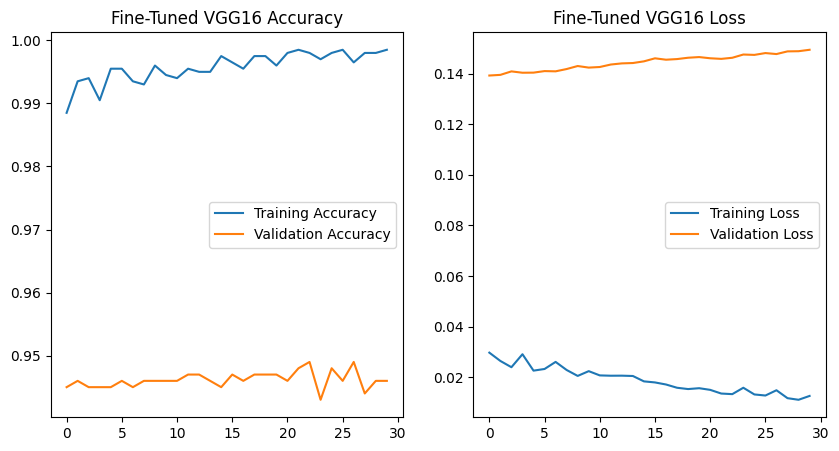

<Figure size 640x480 with 0 Axes>

In [69]:
acc = vgg_finetune_history.history["accuracy"]
val_acc = vgg_finetune_history.history["val_accuracy"]
loss = vgg_finetune_history.history["loss"]
val_loss = vgg_finetune_history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Fine-Tuned VGG16 Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("Fine-Tuned VGG16 Loss")

plt.show()

save_plot("vgg_after_finetuning.png")

### 📊 Fine-Tuned VGG16 Performance Analysis

After applying fine-tuning to VGG16, the training accuracy remains extremely high, consistently close to 100%, indicating that the model continues to fit the training data very well.

However, the validation accuracy shows only minimal improvement compared to the pre-fine-tuning stage, remaining around 94%–95%. At the same time, the validation loss continues to increase steadily while the training loss decreases.

This pattern clearly indicates that fine-tuning does not improve generalization for this model. Instead, it intensifies overfitting by allowing the model to adapt too closely to the training data.

Overall, the results suggest that VGG16 is already sufficiently expressive for this task, and additional fine-tuning introduces unnecessary complexity, reducing its ability to generalize to unseen data.

## 📱 MobileNetV2 Evaluation

### Test Accuracy

The best saved MobileNetV2 model is evaluated on the test dataset to measure its final performance.

In [73]:
test_dataset_mobilenet = test_dataset_mobilenet.apply(
    tf.data.experimental.ignore_errors()
)

mobilenet_test_loss, mobilenet_test_acc = mobilenet_model.evaluate(test_dataset_mobilenet)

print("MobileNetV2 Test Accuracy:", mobilenet_test_acc)
print("MobileNetV2 Test Loss:", mobilenet_test_loss)    

61/61 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.9840 - loss: 0.0425
MobileNetV2 Test Accuracy: 0.9839876294136047
MobileNetV2 Test Loss: 0.04253087192773819


d:\Study\Applied Artificial Intelligence & Machine Learning 1\Foundations of Machine Learning Frameworks\Lab\Lab 3\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


### Test Performance

The MobileNetV2 model achieves a test accuracy of approximately **98.4%** with a low test loss of **0.0425**, indicating excellent generalization performance on unseen data.

The high accuracy combined with low loss suggests that the model is both confident and correct in its predictions, and that overfitting is minimal.

### Confusion Matrix

The confusion matrix provides a detailed view of correct and incorrect predictions across classes.

In [74]:
y_true = []
y_pred = []

for images, labels in test_dataset_mobilenet:
    preds = mobilenet_model.predict(images)
    preds = (preds > 0.5).astype(int)
    
    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

cm = confusion_matrix(y_true, y_pred)
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1

### Confusion Matrix Analysis

The confusion matrix shows that the model correctly classifies the vast majority of samples in both classes. Only a small number of misclassifications are observed.

Both false positives and false negatives are very low, indicating that the model performs consistently well across both categories and does not exhibit bias toward a particular class.

### Precision, Recall, F1-Score

These metrics provide a more comprehensive evaluation of the model’s performance.

In [75]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       967
           1       0.98      0.98      0.98       969

    accuracy                           0.98      1936
   macro avg       0.98      0.98      0.98      1936
weighted avg       0.98      0.98      0.98      1936



### Classification Metrics

The model achieves high precision, recall, and F1-score (all approximately **0.98**), demonstrating strong and balanced performance.

High precision indicates that the model makes very few incorrect positive predictions, while high recall shows that it successfully identifies most of the true positive samples. The high F1-score confirms that the model maintains a good balance between these two metrics.

### Precision-Recall Curve

The precision-recall curve shows the trade-off between precision and recall at different thresholds.

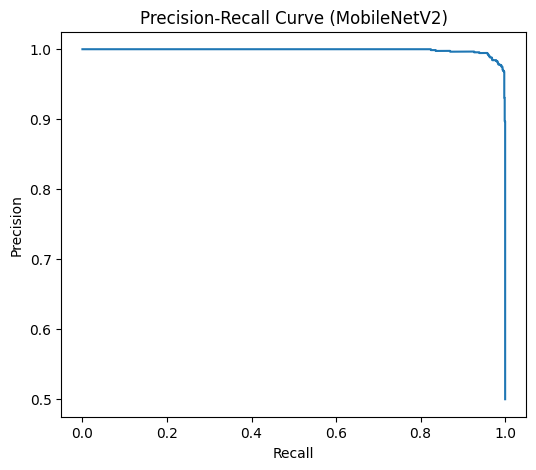

<Figure size 640x480 with 0 Axes>

In [81]:
y_true = []
y_scores = []

for images, labels in test_dataset_mobilenet:
    preds = mobilenet_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_scores.extend(preds.flatten()) 

precision, recall, _ = precision_recall_curve(y_true, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (MobileNetV2)")

plt.show()

save_plot("pr_curve_mobilenet.png")

### Precision-Recall Curve Analysis

The precision-recall curve remains close to 1.0 across almost the entire range of recall values, indicating that the model maintains very high precision while achieving high recall.

A slight drop in precision is observed only when recall approaches 1.0, which is expected as lowering the classification threshold introduces more false positives.

Overall, the curve demonstrates that the model is highly effective at distinguishing between the two classes.

### Error Analysis

This section visualizes examples where the model makes incorrect predictions, helping identify its weaknesses.

In [84]:
wrong_images = []
wrong_preds = []
wrong_labels = []

for images, labels in test_dataset_mobilenet:
    preds = mobilenet_model.predict(images, verbose=0)
    pred_labels = (preds > 0.5).astype(int).flatten()

    for i in range(len(pred_labels)):
        if pred_labels[i] != labels[i]:
            wrong_images.append(images[i].numpy())
            wrong_preds.append(pred_labels[i])
            wrong_labels.append(int(labels[i].numpy()))

    if len(wrong_images) >= 6:
        break

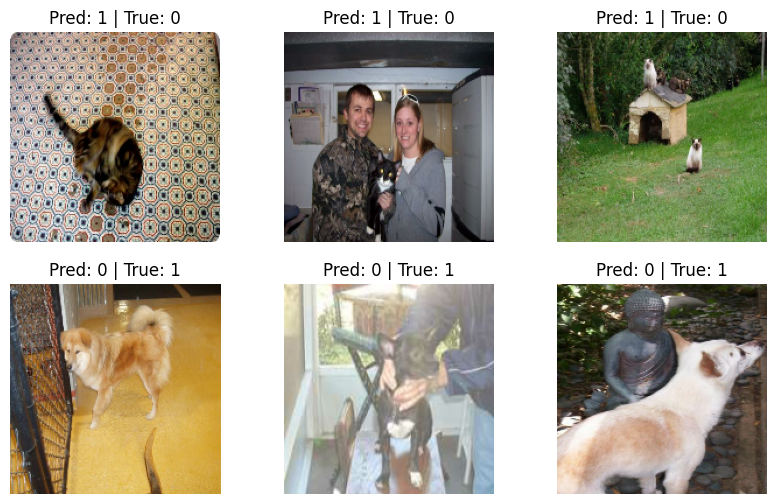

<Figure size 640x480 with 0 Axes>

In [85]:
plt.figure(figsize=(10, 6))

n_show = min(6, len(wrong_images))
for i in range(n_show):
    plt.subplot(2, 3, i + 1)

    img = wrong_images[i]
    img = ((img + 1.0) * 127.5).clip(0, 255).astype("uint8")  # 反归一化

    plt.imshow(img)
    plt.title(f"Pred: {wrong_preds[i]} | True: {wrong_labels[i]}")
    plt.axis("off")

plt.show()

save_plot("mobilenet_errors.png")

### Error Analysis

The misclassified examples reveal several challenging scenarios for the model.

In some cases, the model incorrectly predicts **cats as dogs**, particularly when the visual features are ambiguous, such as unusual poses, similar fur textures, or cluttered backgrounds. For example, images with multiple animals or complex scenes may confuse the model.

Similarly, some **dogs are misclassified as cats**, especially when the dog has features that resemble cats (e.g., small size, posture, or lighting conditions). Poor image quality, motion blur, or partial occlusion also contribute to these errors.

Additionally, certain images contain distracting elements such as humans or objects, which may shift the model’s attention away from the animal and lead to incorrect predictions.

Overall, although the number of errors is very small, these cases highlight that the model can struggle with:
- visually ambiguous samples  
- complex backgrounds  
- low-quality or blurred images  

This suggests that further improvements could be achieved through data augmentation or more robust feature learning.

## 🧠 VGG16 Evaluation

### Test Accuracy

The VGG16 model is evaluated on the test dataset to measure its final performance.

In [87]:
import tensorflow as tf

test_dataset_vgg = test_dataset_vgg.apply(
    tf.data.experimental.ignore_errors()
)

vgg_test_loss, vgg_test_acc = vgg_model.evaluate(test_dataset_vgg)

print("VGG16 Test Accuracy:", vgg_test_acc)
print("VGG16 Test Loss:", vgg_test_loss)

61/61 ━━━━━━━━━━━━━━━━━━━━ 42s 685ms/step - accuracy: 0.9421 - loss: 0.1389
VGG16 Test Accuracy: 0.942148745059967
VGG16 Test Loss: 0.13893017172813416


d:\Study\Applied Artificial Intelligence & Machine Learning 1\Foundations of Machine Learning Frameworks\Lab\Lab 3\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


### Test Performance

The VGG16 model achieved a test accuracy of approximately **94.2%** and a test loss of **0.139**.

This indicates that the model performs well overall in classifying images into the two categories. The relatively low loss value suggests that the model predictions are generally confident and aligned with the true labels.

However, the accuracy is not perfect, indicating that there are still some misclassified examples, which will be further analyzed in the following sections.


### Confusion Matrix

The confusion matrix provides a detailed breakdown of correct and incorrect predictions.

In [88]:
y_true = []
y_pred = []

for images, labels in test_dataset_vgg:
    preds = vgg_model.predict(images, verbose=0)
    pred_labels = (preds > 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[912  58]
 [ 52 914]]


### Confusion Matrix Analysis

The confusion matrix is shown below:

- True Negatives (Correctly predicted class 0): 912  
- False Positives (Incorrectly predicted class 1): 58  
- False Negatives (Incorrectly predicted class 0): 52  
- True Positives (Correctly predicted class 1): 914  

The confusion matrix shows that the model performs fairly well on both classes, with a similar number of correct predictions for each class.

The number of false positives and false negatives is relatively low, indicating balanced performance. However, the presence of these misclassifications suggests that the model still struggles with certain ambiguous or difficult images.


### Precision, Recall, F1-score

These metrics evaluate the classification performance from different perspectives.

In [89]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94       970
           1       0.94      0.95      0.94       966

    accuracy                           0.94      1936
   macro avg       0.94      0.94      0.94      1936
weighted avg       0.94      0.94      0.94      1936



### Classification Metrics

The classification report shows the following results:

- Precision ≈ 0.94 for both classes  
- Recall ≈ 0.94–0.95  
- F1-score ≈ 0.94  

These results indicate that the model maintains a good balance between precision and recall. The similar values across both classes suggest that the model does not favor one class over the other.

The F1-score confirms that the model achieves consistent performance by balancing false positives and false negatives effectively.


### Precision-Recall Curve

The curve illustrates the trade-off between precision and recall across different thresholds.

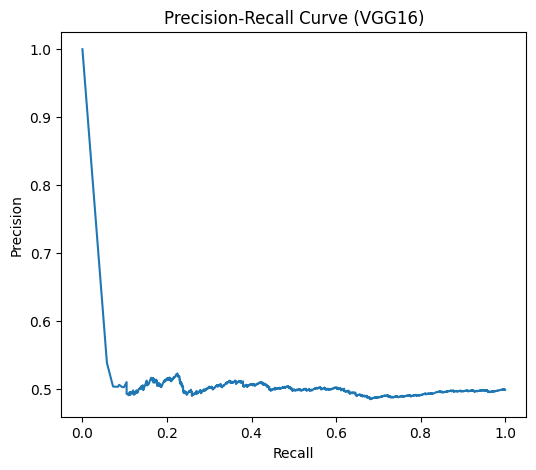

<Figure size 640x480 with 0 Axes>

In [90]:
y_scores = []

for images, labels in test_dataset_vgg:
    preds = vgg_model.predict(images, verbose=0)
    y_scores.extend(preds.flatten())

precision, recall, _ = precision_recall_curve(y_true, y_scores)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (VGG16)")

plt.show()

save_plot("pr_curve_vgg16.png")

### Precision-Recall Curve Analysis

The precision-recall curve shows that precision decreases as recall increases.

At very low recall values, the model achieves high precision, meaning that when it is very confident, it is usually correct. However, as the model attempts to capture more positive samples (higher recall), precision drops and stabilizes around **0.5**.

This indicates that the model becomes less reliable when trying to identify more positive cases, resulting in an increased number of false positives.

Overall, the curve suggests that the model has moderate discriminative ability and struggles to maintain high precision across all recall levels.


### Error Analysis

Misclassified samples are collected to understand model limitations.

In [94]:
test_dataset_raw = image_dataset_from_directory(
    base_dir / "test",
    image_size=(180, 180),
    batch_size=32,
    shuffle=False 
)

Found 2000 files belonging to 2 classes.


In [95]:
wrong_images = []
wrong_preds = []
wrong_labels = []

for (raw_images, labels), (proc_images, _) in zip(test_dataset_raw, test_dataset_vgg):

    preds = vgg_model.predict(proc_images, verbose=0)
    pred_labels = (preds > 0.5).astype(int).flatten()

    for i in range(len(pred_labels)):
        if pred_labels[i] != labels[i]:
            wrong_images.append(raw_images[i].numpy().astype("uint8"))
            wrong_preds.append(pred_labels[i])
            wrong_labels.append(int(labels[i].numpy()))

    if len(wrong_images) >= 6:
        break

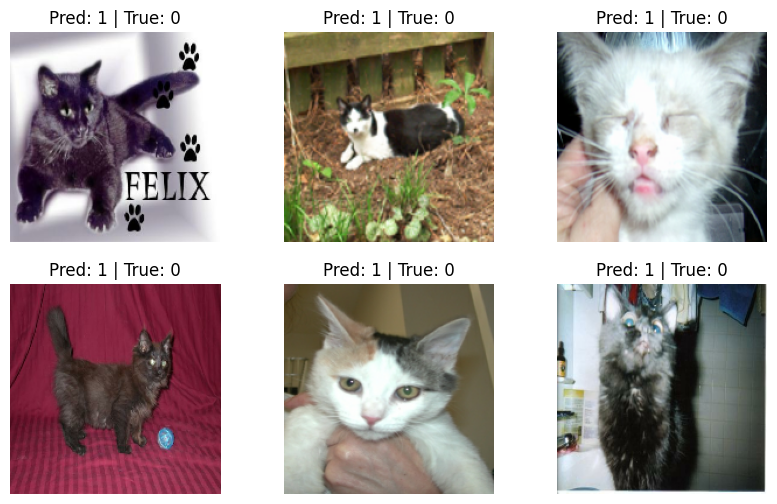

<Figure size 640x480 with 0 Axes>

In [98]:
plt.figure(figsize=(10, 6))

for i in range(min(6, len(wrong_images))):
    plt.subplot(2, 3, i + 1)
    plt.imshow(wrong_images[i])
    plt.title(f"Pred: {wrong_preds[i]} | True: {wrong_labels[i]}")
    plt.axis("off")

plt.show()

save_plot("vgg16_errors.png")

### Error Analysis

The misclassified examples reveal several patterns that help explain the model's errors.

Most of the incorrect predictions correspond to **cats being misclassified as dogs**. These images often contain unusual visual characteristics, such as strong lighting, blur, or low image quality. In some cases, the cats appear in uncommon poses or are partially obscured, making it difficult for the model to identify typical features.

Additionally, some images include distracting elements such as text, objects, or complex backgrounds. For example, images with strong color contrast or additional visual noise may interfere with the model’s ability to focus on relevant features.

Another common issue is that certain cats exhibit features that resemble dogs, such as body shape or fur texture, which may confuse the model.

Overall, these errors suggest that the model relies heavily on prominent visual patterns and may struggle when those patterns are unclear, distorted, or misleading.

## 🔍 Model Comparison

In this section, the performance of MobileNetV2 and VGG16 is compared based on multiple evaluation metrics, including accuracy, confusion matrix, classification report, precision-recall curve, and error analysis.

---

### Overall Accuracy

MobileNetV2 achieved a test accuracy of approximately **98.4%**, while VGG16 achieved around **94.2%**.

This indicates that MobileNetV2 provides significantly better overall classification performance. The higher accuracy suggests that MobileNetV2 is more effective at learning discriminative features from the dataset.

---

### Confusion Matrix and Classification Metrics

MobileNetV2 shows fewer misclassifications in both false positives and false negatives, resulting in higher precision, recall, and F1-scores (around **0.98**).

In contrast, VGG16 achieves slightly lower scores (around **0.94**) and produces more classification errors. While both models maintain balanced performance across classes, MobileNetV2 demonstrates stronger consistency and reliability.

---

### Precision-Recall Curve

The precision-recall curve for MobileNetV2 remains close to the top-right corner, indicating that the model maintains high precision across most recall levels.

On the other hand, VGG16 shows a noticeable drop in precision as recall increases, suggesting that it struggles to maintain prediction confidence when identifying more positive samples.

This indicates that MobileNetV2 has better discriminative power and is more robust across different decision thresholds.

---

### Error Analysis

MobileNetV2 produces fewer misclassified examples overall and tends to handle challenging images more effectively.

VGG16, however, makes more errors in cases involving:
- complex backgrounds  
- poor lighting  
- blurred or low-quality images  
- visually ambiguous features  

These findings suggest that MobileNetV2 is more robust to variations in image quality and visual complexity.

---

### Model Efficiency and Design

MobileNetV2 is designed as a lightweight architecture optimized for efficiency, which allows it to generalize well even with fewer parameters.

VGG16, being a deeper and heavier model, requires more computational resources but does not necessarily translate this complexity into better performance in this task.

---

### Final Conclusion

Overall, MobileNetV2 outperforms VGG16 across all evaluation metrics, including accuracy, precision, recall, F1-score, and precision-recall behavior.

The results suggest that a more efficient and modern architecture like MobileNetV2 can achieve superior performance compared to a traditional deep network such as VGG16.

Therefore, MobileNetV2 is the preferred model for this classification task due to its higher accuracy, better generalization, and stronger robustness to challenging image conditions.

### Thinking Points — MobileNetV2

1. MobileNetV2 is surprisingly very strong even though it is a lightweight model. I think maybe because it is more modern architecture, so it can capture useful features more efficiently.

2. The model shows very high accuracy and also stable performance during training. It seems not easily overfitting, which is kind of unexpected for such high accuracy.

3. From the precision-recall curve, the model can maintain high precision even when recall increases. This means it is confident in its predictions most of the time.

4. One interesting thing is that even with fewer parameters, it performs better than VGG16. So more complex model does not always mean better performance.

5. I feel MobileNetV2 is more suitable for real-world application, especially when computation resources are limited, because it is both fast and accurate.

### Thinking Points — VGG16

1. VGG16 is a classical model and works quite well, but its performance is not as strong as expected in this task. Maybe because the architecture is older.

2. The model can achieve decent accuracy, but it makes more mistakes compared to MobileNetV2, especially in difficult images.

3. From the precision-recall curve, we can see the precision drops quickly when recall increases. This means the model becomes less reliable when trying to detect more positive samples.

4. One problem I noticed is that VGG16 seems more sensitive to noise, lighting, and background. It sometimes focus on wrong features.

5. Although VGG16 is deeper and more complex, it does not necessarily learn better representations in this case. So complexity is not always equal to performance.